## IMPORT LIBRARIES

In [14]:
import pandas as pd
import re
from gensim.models import Word2Vec
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading Data ...
df = pd.read_csv("train_data.csv",low_memory=False)

In [3]:
# Reviewing
# df.head(20)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838944 entries, 0 to 838943
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   overall         838944 non-null  int64 
 1   vote            191468 non-null  object
 2   verified        838944 non-null  bool  
 3   reviewTime      838944 non-null  object
 4   reviewerID      838944 non-null  object
 5   asin            838944 non-null  object
 6   style           490613 non-null  object
 7   reviewerName    838717 non-null  object
 8   reviewText      838944 non-null  object
 9   summary         838868 non-null  object
 10  unixReviewTime  838944 non-null  int64 
dtypes: bool(1), int64(2), object(8)
memory usage: 64.8+ MB


## PREPROCESSING

In [4]:
df1 = df[["asin","overall","reviewText","summary"]].copy()
df1["reviewText"] = df1["reviewText"].astype(str)
df1["reviewText"] = df1["reviewText"].str.lower()
df1["reviewText"] = df1["reviewText"].apply(lambda x : re.sub(r"[^\w\s]", "",x))
df1["reviewText"] = df1["reviewText"].apply(lambda x : re.sub(r"\d+", "",x))
stop_words = set(stopwords.words("english"))
df1["reviewText"] = df1["reviewText"].apply(lambda x : " ".join(word for word in x.split() if word not in stop_words))

## TRAINING MODEL

In [5]:
sentences = df1["reviewText"].apply(str.split).tolist()
model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4)
model.wv.most_similar("warranty", topn=10)
similar_words = ["warranty"]
for word, similarity in model.wv.most_similar("warranty", topn=30):
    if similarity >= 0.6:
        similar_words.append(word)
print(similar_words)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


...

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


['warranty', 'warrantee', 'warrenty', 'warranties', 'warantee', 'warrantied', 'squaretrade', 'guarantee', 'guaranty', 'warrantya', 'assurant', 'asurion', 'contract', 'waranty', 'policy', 'rma', 'warrantybut']


In [6]:
for word, similarity in model.wv.most_similar("warranty", topn=30):
    print(word, similarity)

warrantee 0.9220435619354248
warrenty 0.9072279930114746
warranties 0.8617141246795654
warantee 0.7604682445526123
warrantied 0.7511424422264099
squaretrade 0.7124018669128418
guarantee 0.7011353969573975
guaranty 0.6799205541610718
warrantya 0.661108136177063
assurant 0.6513816714286804
asurion 0.65013188123703
contract 0.6413164734840393
waranty 0.628240168094635
policy 0.6270754933357239
rma 0.6220224499702454
warrantybut 0.6209976077079773
honored 0.5958066582679749
expire 0.5890753269195557
rebate 0.5887775421142578
expired 0.5871288180351257
nextbusinessday 0.586236834526062
honor 0.5822001695632935
manufacture 0.5753269195556641
worryfree 0.5718705058097839
declined 0.5717271566390991
expires 0.5706241726875305
smartguard 0.5689215064048767
manufacturer 0.5499805808067322
receipt 0.5442919731140137
repairreplacement 0.5420212745666504


In [7]:
def contains_aspect(text, words):
    return any(word in text for word in words)
df1["has_warranty"] = df1["reviewText"].apply(lambda x: contains_aspect(x, similar_words))

In [8]:
df1[["reviewText", "has_warranty"]].head()

,reviewText,has_warranty
0,older urcwr remote thought would upgrade twc s...,False
1,first time ive ever remote needed programming ...,False
2,got worked company called feedback told would ...,False
3,got tired remote wrong side bed going buy gene...,False
4,purchasing cheap cords another website little ...,False


In [9]:
# Result
warranty_reviews = df1[df1["has_warranty"] == True]
result = (warranty_reviews.groupby("asin")["overall"].mean().reset_index())
result = result.rename(columns={"overall": "warranty_satisfaction"})

In [13]:
result.head(20)

,asin,warranty_satisfaction
0,0545105668,5.0
1,140053271X,5.0
2,1495443043,5.0
3,6541654530,1.0
4,6575464564,5.0
5,9565727689,3.0
6,9573212919,1.0
7,980035977X,3.0
8,9800466657,5.0
9,987598180X,5.0


## CONCLUSION
### Used Word2Vec to identify related terms and analyzed the data based on these terms. The results were then used to calculate and compare satisfaction scores for different products.



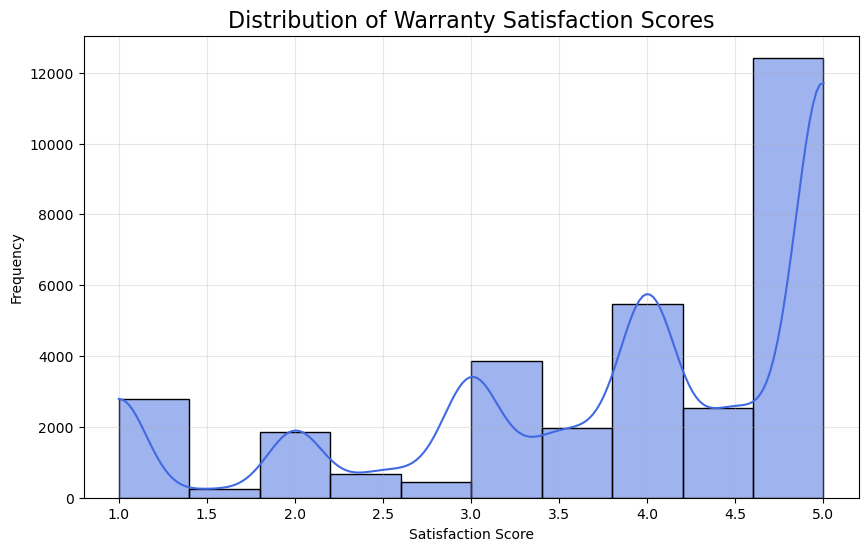

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(
    result['warranty_satisfaction'],
    bins=10,
    kde=True,
    color='royalblue',
    edgecolor='black')
plt.title("Distribution of Warranty Satisfaction Scores", fontsize=16)
plt.xlabel("Satisfaction Score")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.savefig("Distribution of Warranty Satisfaction Scores", dpi=300, bbox_inches="tight")
plt.show()